In [69]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import matplotlib.text


In [70]:
import sys
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<function atlasopenmagic.utils.install_from_environment(*packages: str | None, environment_file: str | None = None) -> None>

In [71]:
import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [72]:
skim = '2to4lep'
files_list = atom.get_urls('data', skim, protocol = 'https', cache=True)

In [73]:
files_list

['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodD.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodE.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodF.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodG.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodH.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodJ.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data16_periodA.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data16

In [74]:
tree_dict = uproot.open(files_list[0])

In [75]:
tree_dict.keys()

['analysis;1']

In [76]:
analysis = uproot.open(files_list[0] + ':analysis')

In [77]:
analysis.show(filter_name = 'lep_*')

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
lep_n                | int32_t                  | AsDtype('>i4')
lep_type             | RVec<int32_t>            | AsJagged(AsDtype('>i4'), he...
lep_pt               | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_eta              | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_phi              | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_e                | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_charge           | RVec<int32_t>            | AsJagged(AsDtype('>i4'), he...
lep_ptvarcone30      | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_topoetcone20     | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_z0               | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_d0               | RVec<float>          

In [78]:
attributes = ['pt','eta','phi','e','charge','flavor','isTightID']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                               'charge':'lep_charge','flavor':'lep_type','isTightID':'lep_isTightID'}
leps = analysis.arrays(attributes, aliases = aliases_dict)

In [79]:
leps.fields

['pt', 'eta', 'phi', 'e', 'charge', 'flavor', 'isTightID']

In [80]:
leps[:, 0]

<Array [{pt: 39.4, eta: -1.46, ...}, ...] type='880210 * {pt: float32, eta:...'>

In [81]:
sorter = np.argsort(leps.pt, axis=1)[:,::-1]

In [82]:
leps = leps[sorter][:, :2]

In [83]:
charge_cut = leps.charge[:, 0] + leps.charge[:, 1] == 0
flavor_cut = leps.flavor[:, 0] == leps.flavor[:, 1]
tight_cut = (leps.isTightID[:, 0] & leps.isTightID[:, 1])

In [84]:
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sin(leps.eta)

In [85]:
sum_px = px[:, 0] + px[:, 1]
sum_py = py[:, 0] + py[:, 1]
sum_pz = pz[:, 0] + pz[:, 1]
sum_e = leps.e[:, 0] + leps.e[:, 1]

In [86]:
masses = np.sqrt(np.abs(sum_e**2-sum_px**2-sum_py**2-sum_pz**2))

In [87]:
cut_masses = masses[charge_cut & flavor_cut & tight_cut]

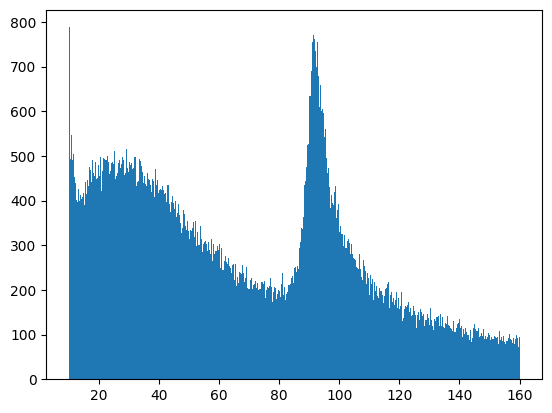

In [88]:
plt.hist(cut_masses, bins=500, range=(10,160))
plt.show()

In [90]:
x_min, x_max = 10,160
bin_width = 1

In [91]:
bin_edges = np.arange(start = x_min, stop = x_max+1, step = bin_width)
bin_centers = bin_edges[:-1]+bin_width/2

In [92]:
counts, _ = np.histogram(cut_masses, bins=bin_edges)

In [ ]:
count_errors = np.sqrt(counts)

<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/z7/scmmns7s1vs0_xsjtblxqwkm0000gp/T/ipykernel_32835/3008894241.py:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Di-lepton invarient mass [${m_{\mu\mu} \ or \ m_{ee}}$]', x=1, horizontalalignment = 'right')


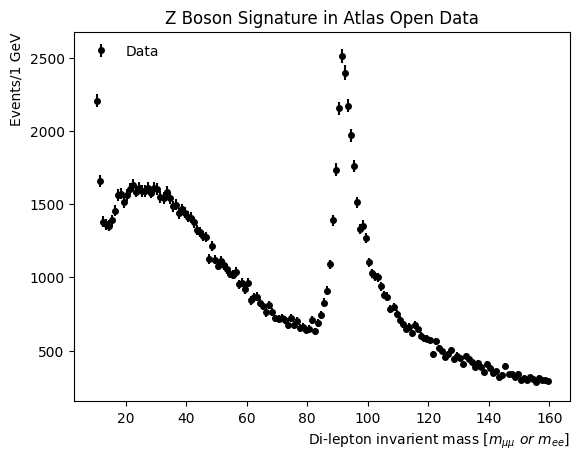

In [94]:
# initial parameters
x_min, x_max = 10,160
bin_width = 1
bin_edges = np.arange(start = x_min, stop = x_max+1, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2
counts, _ = np.histogram(cut_masses, bins=bin_edges)
count_errors = np.sqrt(counts)

#plot
plt.errorbar(x = bin_centers, y = counts, yerr = count_errors, fmt = 'ko', label = 'Data', markersize = 4)
plt.title('Z Boson Signature in Atlas Open Data')
plt.xlabel('Di-lepton invarient mass [${m_{\mu\mu} \ or \ m_{ee}}$]', x=1, horizontalalignment = 'right')
plt.ylabel('Events/' + str(bin_width) + ' GeV', y=1, horizontalalignment = 'right')
plt.legend(frameon = False, loc = 'upper left')
plt.show()